### 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.3f}'.format)

# Base algorithms (from validation results)
BASE_ALGOS = ['rl', 'll', 'dal', 'dsb', 'rrsplit', 'symsplit', 'mcsplit']

# Ablation variants
ABLATION_ALGOS = [
    'll_lsm', 'll_lum', 'll_none',
    'dal_rl', 'dal_dal',
    'dsb_always', 'dsb_never',
    'rrsplit_noveq', 'rrsplit_nomax', 'rrsplit_nobound',
    'symsplit_valonly', 'symsplit_varonly'
]

ALL_ALGOS = BASE_ALGOS + ABLATION_ALGOS

# Paths
VALIDATION_DIR = Path('../../hpc/validation/results')
ABLATION_DIR = Path('../../hpc/ablation/results')

COLS = [
    'instance_a', 'instance_b', 'algo',
    'unified_size', 'unified_edges', 'unified_nodes', 'unified_time',
    'unified_aborted', 'unified_nodes_to_best',
    'unified_time_to_best', 'unified_cut_branches', 'unified_bound_pruned',
    'unified_sym_pruned',
]

TIMEOUT = 1000.0
EASY_THRESHOLD = 10.0
inst_key = ['instance_a', 'instance_b']

### 2. Load Data

In [ ]:
dfs = []

# Load base algorithms from validation results
for algo in BASE_ALGOS:
    path = VALIDATION_DIR / f'{algo}_all.csv'
    if not path.exists():
        print(f'WARNING: {path} not found, skipping {algo}')
        continue
    df = pd.read_csv(path, header=None)
    # Validation CSVs have ref columns too — take only the unified columns
    df = df.iloc[:, :15]
    df.columns = COLS
    dfs.append(df)
    print(f'Loaded base {algo}: {len(df)} rows')

# Load ablation variants
for algo in ABLATION_ALGOS:
    path = ABLATION_DIR / f'{algo}_all.csv'
    if not path.exists():
        print(f'WARNING: {path} not found, skipping {algo}')
        continue
    df = pd.read_csv(path, header=None, skipinitialspace=True)
    df = df.iloc[:, :15]  # take first 15 columns, drop trailing comma column
    df.columns = COLS
    df = df[df['algo'] == algo].copy()  # drop header rows
    dfs.append(df)
    print(f'Loaded ablation {algo}: {len(df)} rows')

all_data = pd.concat(dfs, ignore_index=True)

# Coerce numeric columns
num_cols = ['unified_size', 'unified_nodes', 'unified_time', 'unified_aborted',
            'unified_nodes_to_best', 'unified_time_to_best',
            'unified_cut_branches', 'unified_bound_pruned', 'unified_sym_pruned']
for col in num_cols:
    all_data[col] = pd.to_numeric(all_data[col], errors='coerce')

# Drop header rows that leaked during CSV concatenation
all_data = all_data[all_data['algo'].isin(ALL_ALGOS)].copy()

print(f'\nTotal rows: {len(all_data)}')
print(all_data['algo'].value_counts())

Loaded base rl: 8141 rows
Loaded base ll: 8141 rows
Loaded base dal: 8141 rows
Loaded base dsb: 8141 rows
Loaded base rrsplit: 8141 rows
Loaded base symsplit: 8141 rows
Loaded base mcsplit: 8141 rows
Loaded ablation ll_lsm: 8140 rows
Loaded ablation ll_lum: 8140 rows
Loaded ablation ll_none: 8140 rows
Loaded ablation dal_rl: 8140 rows
Loaded ablation dal_dal: 8140 rows
Loaded ablation dsb_always: 8140 rows
Loaded ablation dsb_never: 8140 rows
Loaded ablation rrsplit_noveq: 8140 rows
Loaded ablation rrsplit_nomax: 8140 rows
Loaded ablation rrsplit_nobound: 8140 rows
Loaded ablation symsplit_valonly: 8140 rows
Loaded ablation symsplit_varonly: 8140 rows

Total rows: 154660
algo
rl                  8140
ll                  8140
dal                 8140
dsb                 8140
rrsplit             8140
symsplit            8140
mcsplit             8140
ll_lsm              8140
ll_lum              8140
ll_none             8140
dal_rl              8140
dal_dal             8140
dsb_always     

### 3. Difficulty Classification

Use the same medium instance set from the validation analysis — instances where at least one algorithm solves it but not all solve it quickly.

In [17]:
# Use only the 7 base algorithms to classify difficulty
# (ablation variants shouldn't change the difficulty classification)
base_data = all_data[all_data['algo'].isin(BASE_ALGOS)].copy()

solved = base_data.copy()
solved['solve_time'] = solved.apply(
    lambda r: r['unified_time'] if r['unified_aborted'] == 0 else np.nan, axis=1
)

time_pivot = solved.pivot_table(
    index=inst_key, columns='algo', values='solve_time', aggfunc='first'
)
abort_pivot = solved.pivot_table(
    index=inst_key, columns='algo', values='unified_aborted', aggfunc='first'
)

abort_pivot_filled = abort_pivot.fillna(1).astype(int)

all_instances = base_data[inst_key].drop_duplicates().set_index(inst_key).index

def classify_instance(idx):
    if idx not in abort_pivot_filled.index:
        return 'hard'
    row_abort = abort_pivot_filled.loc[idx]
    row_time = time_pivot.loc[idx] if idx in time_pivot.index else pd.Series(dtype=float)
    n_solved = (row_abort == 0).sum()
    n_with_data = row_abort.notna().sum()
    n_fast = (row_time <= EASY_THRESHOLD).sum()
    if n_with_data == 0:
        return 'no_data'
    if n_solved == 0:
        return 'hard'
    if n_fast == n_with_data:
        return 'easy'
    return 'medium'

difficulty = pd.Series(
    [classify_instance(idx) for idx in all_instances],
    index=all_instances, name='difficulty'
)

print('Difficulty distribution (base algorithms):')
print(difficulty.value_counts().to_string())

medium_instances = set(difficulty[difficulty == 'medium'].index)
print(f'\nMedium instances: {len(medium_instances)}')

Difficulty distribution (base algorithms):
difficulty
hard      4160
easy      2898
medium    1082

Medium instances: 1082


### 4. Instances Solved on Medium Set — All Algorithms

In [18]:
# Filter all data to medium instances
med_mask = all_data.set_index(inst_key).index.isin(medium_instances)
medium_data = all_data[med_mask].copy()

def medium_summary(data, algos):
    rows = []
    for algo in algos:
        sub = data[data['algo'] == algo]
        if sub.empty:
            continue
        solved = (sub['unified_aborted'] == 0).sum()
        total = len(sub)
        mean_time = sub.loc[sub['unified_aborted'] == 0, 'unified_time'].mean()
        mean_nodes = sub.loc[sub['unified_aborted'] == 0, 'unified_nodes'].mean()
        rows.append({
            'algo': algo,
            'medium_total': total,
            'solved': solved,
            'solved_pct': 100 * solved / total if total > 0 else 0,
            # 'mean_time': mean_time,
            # 'mean_nodes': mean_nodes
        })
    return pd.DataFrame(rows).set_index('algo')

In [19]:
print('All algorithms — medium instance performance:')
summary = medium_summary(medium_data, ALL_ALGOS)
print(summary.round(2))

All algorithms — medium instance performance:
                  medium_total  solved  solved_pct
algo                                              
rl                        1082     976      90.200
ll                        1082    1026      94.820
dal                       1082     996      92.050
dsb                       1082    1030      95.190
rrsplit                   1082    1057      97.690
symsplit                  1082    1071      98.980
mcsplit                   1082    1037      95.840
ll_lsm                    1082    1018      94.090
ll_lum                    1082    1017      93.990
ll_none                   1082    1047      96.770
dal_rl                    1082     849      78.470
dal_dal                   1082     842      77.820
dsb_always                1082    1037      95.840
dsb_never                 1082    1036      95.750
rrsplit_noveq             1082    1064      98.340
rrsplit_nomax             1082    1067      98.610
rrsplit_nobound           1082    10

In [20]:
# Do ll_none and rl agree on solution sizes on completed instances?
ll_none_data = medium_data[medium_data['algo'] == 'll_none'].set_index(inst_key)
rl_data = medium_data[medium_data['algo'] == 'rl'].set_index(inst_key)
common = ll_none_data.index.intersection(rl_data.index)

both_completed = common[
    (ll_none_data.loc[common, 'unified_aborted'] == 0) &
    (rl_data.loc[common, 'unified_aborted'] == 0)
]
size_agree = (ll_none_data.loc[both_completed, 'unified_size'] == 
              rl_data.loc[both_completed, 'unified_size']).sum()
print(f'll_none vs rl: {size_agree}/{len(both_completed)} agree on size')

# How many does ll_none solve that rl doesn't?
ll_none_solved = set(ll_none_data[ll_none_data['unified_aborted'] == 0].index)
rl_solved = set(rl_data[rl_data['unified_aborted'] == 0].index)
print(f'll_none solves but rl doesnt: {len(ll_none_solved - rl_solved)}')
print(f'rl solves but ll_none doesnt: {len(rl_solved - ll_none_solved)}')

ll_none vs rl: 975/975 agree on size
ll_none solves but rl doesnt: 72
rl solves but ll_none doesnt: 1


In [21]:
dal_rl_data = medium_data[medium_data['algo'] == 'dal_rl']
print(f'dal_rl aborted: {(dal_rl_data["unified_aborted"] == 1).sum()}')
print(f'dal_rl completed: {(dal_rl_data["unified_aborted"] == 0).sum()}')
print(f'dal_rl empty results: {dal_rl_data["unified_size"].isna().sum()}')

dal_rl aborted: 233
dal_rl completed: 849
dal_rl empty results: 0


In [22]:
for algo in ['rrsplit', 'rrsplit_noveq', 'rrsplit_nomax', 'rrsplit_nobound']:
    sub = medium_data[(medium_data['algo'] == algo) & (medium_data['unified_aborted'] == 0)]
    print(f'{algo}: median_nodes={sub["unified_nodes"].median():.0f} median_time={sub["unified_time"].median():.2f}')

rrsplit: median_nodes=159268126 median_time=62.08
rrsplit_noveq: median_nodes=164292782 median_time=59.67
rrsplit_nomax: median_nodes=164407901 median_time=60.27
rrsplit_nobound: median_nodes=161977254 median_time=58.35


### 5. LL Ablation: LSM vs LUM

LL adds two components to RL: LSM (per-pair long-short memory scoring) and LUM (leaf vertex union matching).
- `ll` = full (both)
- `ll_lsm` = LSM only (no LUM)
- `ll_lum` = LUM only (per-vertex scoring, no per-pair table)
- `ll_none` = neither (should ≈ RL, sanity check)

LL ablation — medium instance performance:


,medium_total,solved,solved_pct
algo,,,
ll,1082,1026,94.820
ll_lum,1082,1017,93.990
ll_lsm,1082,1018,94.090


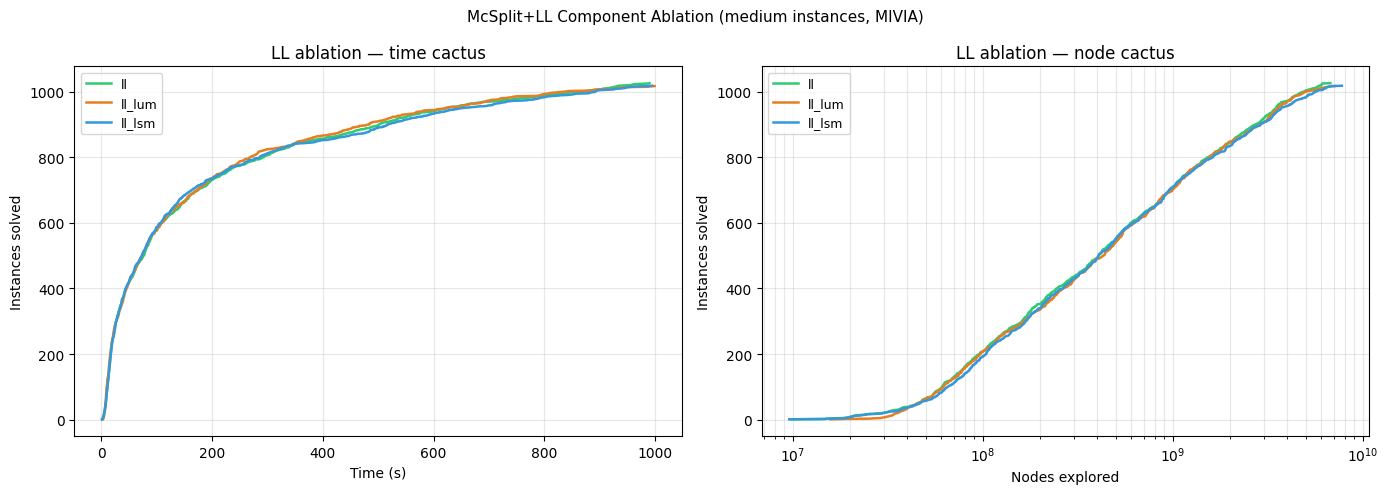

Saved: ll_ablation.png


In [23]:
LL_ALGOS = ['ll', 'll_lum', 'll_lsm']

print('LL ablation — medium instance performance:')
ll_summary = medium_summary(medium_data, LL_ALGOS)
display(ll_summary.round(2))

# Plot: cactus (instances solved vs time)
LL_COLORS = {'ll_none': '#e74c3c', 'll_lum': '#e67e22',
             'll_lsm': '#3498db', 'll': '#2ecc71'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time cactus
for algo in LL_ALGOS:
    sub = medium_data[(medium_data['algo'] == algo) & (medium_data['unified_aborted'] == 0)]
    if sub.empty: continue
    times = sub['unified_time'].sort_values().values
    axes[0].plot(times, np.arange(1, len(times)+1), label=algo,
                 color=LL_COLORS.get(algo, 'gray'), linewidth=1.8)
axes[0].set_ylabel('Instances solved')
axes[0].set_xlabel('Time (s)')
axes[0].set_title('LL ablation — time cactus')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Nodes cactus (log scale)
for algo in LL_ALGOS:
    sub = medium_data[(medium_data['algo'] == algo) & (medium_data['unified_aborted'] == 0)]
    if sub.empty: continue
    nodes = sub['unified_nodes'].sort_values().values
    axes[1].plot(nodes, np.arange(1, len(nodes)+1), label=algo,
                 color=LL_COLORS.get(algo, 'gray'), linewidth=1.8)
axes[1].set_xlabel('Nodes explored')
axes[1].set_ylabel('Instances solved')
axes[1].set_xscale('log')
axes[1].set_title('LL ablation — node cactus')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, which='both')

plt.suptitle('McSplit+LL Component Ablation (medium instances, MIVIA)', fontsize=11)
plt.tight_layout()
plt.savefig('ll_ablation.png', dpi=150)
plt.show()
print('Saved: ll_ablation.png')

### 6. DAL Ablation: Policy Switching

DAL alternates between RL and DAL scoring every MaxNbApp steps.
- `dal` = full hybrid (alternating)
- `dal_rl` = RL policy locked (never switches to DAL)
- `dal_dal` = DAL policy locked (never switches to RL)

Ruth's question: what if we don't switch?

DAL ablation — medium instance performance:


,medium_total,solved,solved_pct
algo,,,
dal,1082,996,92.050
dal_rl,1082,849,78.470
dal_dal,1082,842,77.820


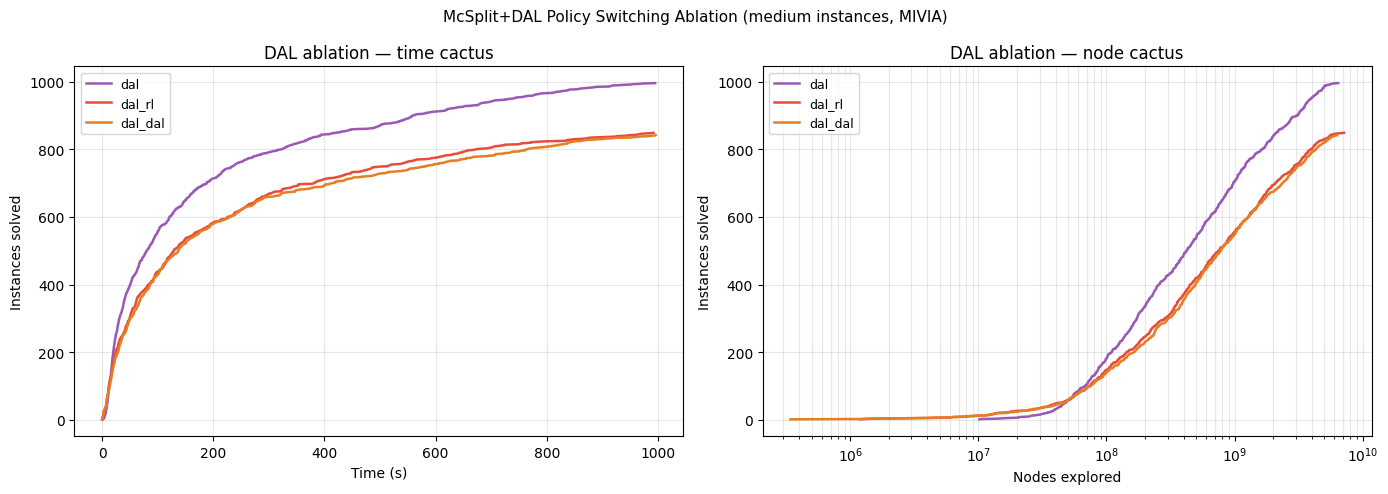

Saved: dal_ablation.png


In [24]:
DAL_ALGOS = ['dal', 'dal_rl', 'dal_dal']

print('DAL ablation — medium instance performance:')
dal_summary = medium_summary(medium_data, DAL_ALGOS)
display(dal_summary.round(2))

DAL_COLORS = {'mcsplit': '#2c3e50', 'rl': '#95a5a6', 'dal_rl': '#e74c3c',
              'dal_dal': '#e67e22', 'dal': '#9b59b6'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for algo in DAL_ALGOS:
    sub = medium_data[(medium_data['algo'] == algo) & (medium_data['unified_aborted'] == 0)]
    if sub.empty: continue
    times = sub['unified_time'].sort_values().values
    axes[0].plot(times, np.arange(1, len(times)+1), label=algo,
                 color=DAL_COLORS.get(algo, 'gray'), linewidth=1.8)
axes[0].set_ylabel('Instances solved')
axes[0].set_xlabel('Time (s)')
axes[0].set_title('DAL ablation — time cactus')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

for algo in DAL_ALGOS:
    sub = medium_data[(medium_data['algo'] == algo) & (medium_data['unified_aborted'] == 0)]
    if sub.empty: continue
    nodes = sub['unified_nodes'].sort_values().values
    axes[1].plot(nodes, np.arange(1, len(nodes)+1), label=algo,
                 color=DAL_COLORS.get(algo, 'gray'), linewidth=1.8)
axes[1].set_xlabel('Nodes explored')
axes[1].set_ylabel('Instances solved')
axes[1].set_xscale('log')
axes[1].set_title('DAL ablation — node cactus')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, which='both')

plt.suptitle('McSplit+DAL Policy Switching Ablation (medium instances, MIVIA)', fontsize=11)
plt.tight_layout()
plt.savefig('dal_ablation.png', dpi=150)
plt.show()
print('Saved: dal_ablation.png')

### 7. DSB Ablation: Bound Gating

- `dsb` = gated (RL-adaptive bound activation)
- `dsb_always` = bound always on
- `dsb_never` = bound never on (= plain McSplit, sanity check)

DSB ablation — medium instance performance:


,medium_total,solved,solved_pct
algo,,,
dsb,1082,1030,95.190
dsb_never,1082,1036,95.750
dsb_always,1082,1037,95.840


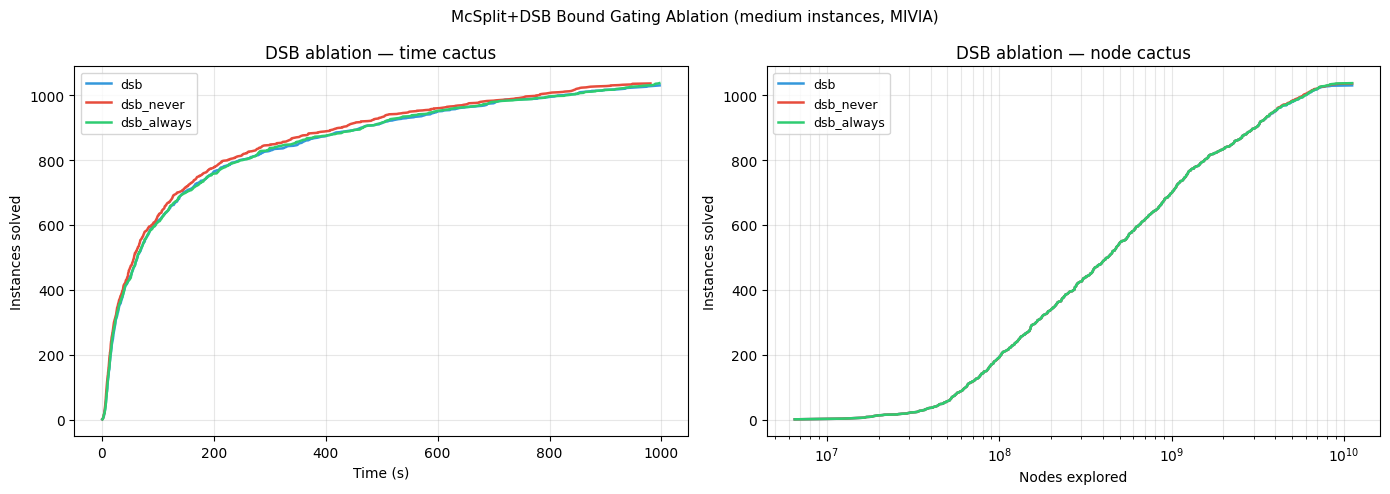

Saved: dsb_ablation.png


In [25]:
DSB_ALGOS = ['dsb', 'dsb_never', 'dsb_always']

print('DSB ablation — medium instance performance:')
dsb_summary = medium_summary(medium_data, DSB_ALGOS)
display(dsb_summary.round(2))

DSB_COLORS = {'mcsplit': '#2c3e50', 'dsb_never': '#e74c3c',
              'dsb': '#3498db', 'dsb_always': '#2ecc71'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for algo in DSB_ALGOS:
    sub = medium_data[(medium_data['algo'] == algo) & (medium_data['unified_aborted'] == 0)]
    if sub.empty: continue
    times = sub['unified_time'].sort_values().values
    axes[0].plot(times, np.arange(1, len(times)+1), label=algo,
                 color=DSB_COLORS.get(algo, 'gray'), linewidth=1.8)
axes[0].set_ylabel('Instances solved')
axes[0].set_xlabel('Time (s)')
axes[0].set_title('DSB ablation — time cactus')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

for algo in DSB_ALGOS:
    sub = medium_data[(medium_data['algo'] == algo) & (medium_data['unified_aborted'] == 0)]
    if sub.empty: continue
    nodes = sub['unified_nodes'].sort_values().values
    axes[1].plot(nodes, np.arange(1, len(nodes)+1), label=algo,
                 color=DSB_COLORS.get(algo, 'gray'), linewidth=1.8)
axes[1].set_xlabel('Nodes explored')
axes[1].set_ylabel('Instances solved')
axes[1].set_xscale('log')
axes[1].set_title('DSB ablation — node cactus')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, which='both')

plt.suptitle('McSplit+DSB Bound Gating Ablation (medium instances, MIVIA)', fontsize=11)
plt.tight_layout()
plt.savefig('dsb_ablation.png', dpi=150)
plt.show()
print('Saved: dsb_ablation.png')

### 8. RRSplit Ablation: Three Reductions

- `rrsplit` = all three on (full)
- `rrsplit_noveq` = no vertex-equivalence reduction
- `rrsplit_nomax` = no maximality reduction
- `rrsplit_nobound` = no tighter bound (plain McSplit bound)

bitmask: bit0=VEQ, bit1=MAX, bit2=BOUND

RRSplit ablation — medium instance performance:


,medium_total,solved,solved_pct
algo,,,
rrsplit,1082,1057,97.690
rrsplit_nobound,1082,1064,98.340
rrsplit_nomax,1082,1067,98.610
rrsplit_noveq,1082,1064,98.340


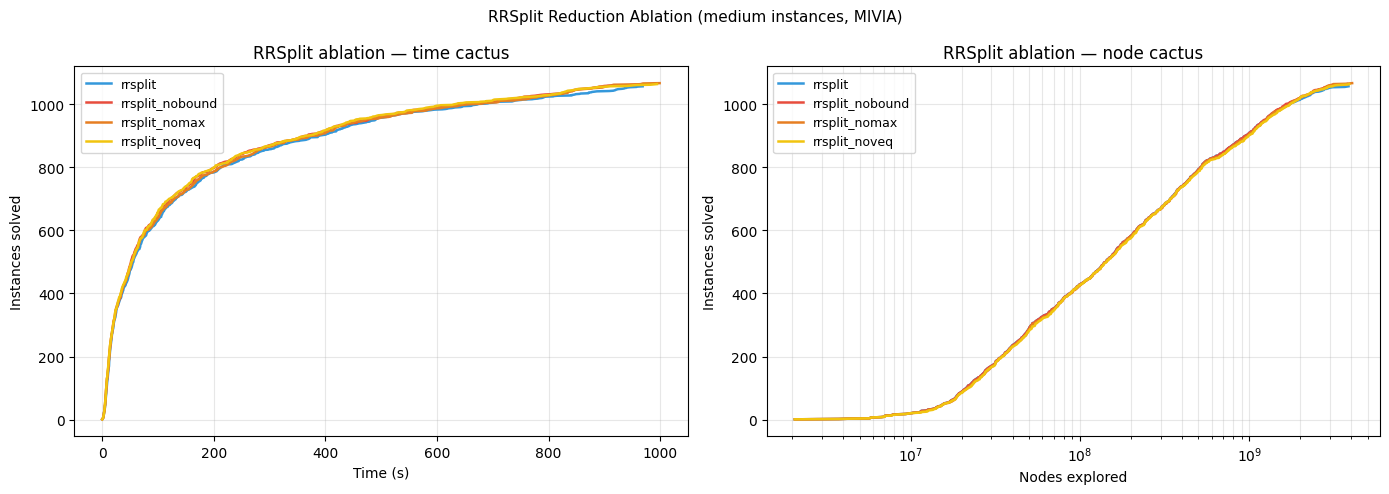

Saved: rrsplit_ablation.png


In [26]:
RR_ALGOS = ['rrsplit', 'rrsplit_nobound', 'rrsplit_nomax', 'rrsplit_noveq']

print('RRSplit ablation — medium instance performance:')
rr_summary = medium_summary(medium_data, RR_ALGOS)
display(rr_summary.round(2))

RR_COLORS = {'mcsplit': '#2c3e50', 'rrsplit_nobound': '#e74c3c',
             'rrsplit_nomax': '#e67e22', 'rrsplit_noveq': '#f1c40f', 'rrsplit': '#3498db'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for algo in RR_ALGOS:
    sub = medium_data[(medium_data['algo'] == algo) & (medium_data['unified_aborted'] == 0)]
    if sub.empty: continue
    times = sub['unified_time'].sort_values().values
    axes[0].plot(times, np.arange(1, len(times)+1), label=algo,
                 color=RR_COLORS.get(algo, 'gray'), linewidth=1.8)
axes[0].set_ylabel('Instances solved')
axes[0].set_xlabel('Time (s)')
axes[0].set_title('RRSplit ablation — time cactus')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

for algo in RR_ALGOS:
    sub = medium_data[(medium_data['algo'] == algo) & (medium_data['unified_aborted'] == 0)]
    if sub.empty: continue
    nodes = sub['unified_nodes'].sort_values().values
    axes[1].plot(nodes, np.arange(1, len(nodes)+1), label=algo,
                 color=RR_COLORS.get(algo, 'gray'), linewidth=1.8)
axes[1].set_xlabel('Nodes explored')
axes[1].set_ylabel('Instances solved')
axes[1].set_xscale('log')
axes[1].set_title('RRSplit ablation — node cactus')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, which='both')

plt.suptitle('RRSplit Reduction Ablation (medium instances, MIVIA)', fontsize=11)
plt.tight_layout()
plt.savefig('rrsplit_ablation.png', dpi=150)
plt.show()
print('Saved: rrsplit_ablation.png')

### 9. SymSplit Ablation: Variable vs Value Symmetry

- `symsplit` = both (full)
- `symsplit_varonly` = variable symmetry only (G-side)
- `symsplit_valonly` = value symmetry only (H-side)

SymSplit ablation — medium instance performance:


,medium_total,solved,solved_pct
algo,,,
symsplit,1082,1071,98.980
symsplit_varonly,1082,1071,98.980
symsplit_valonly,1082,1060,97.970


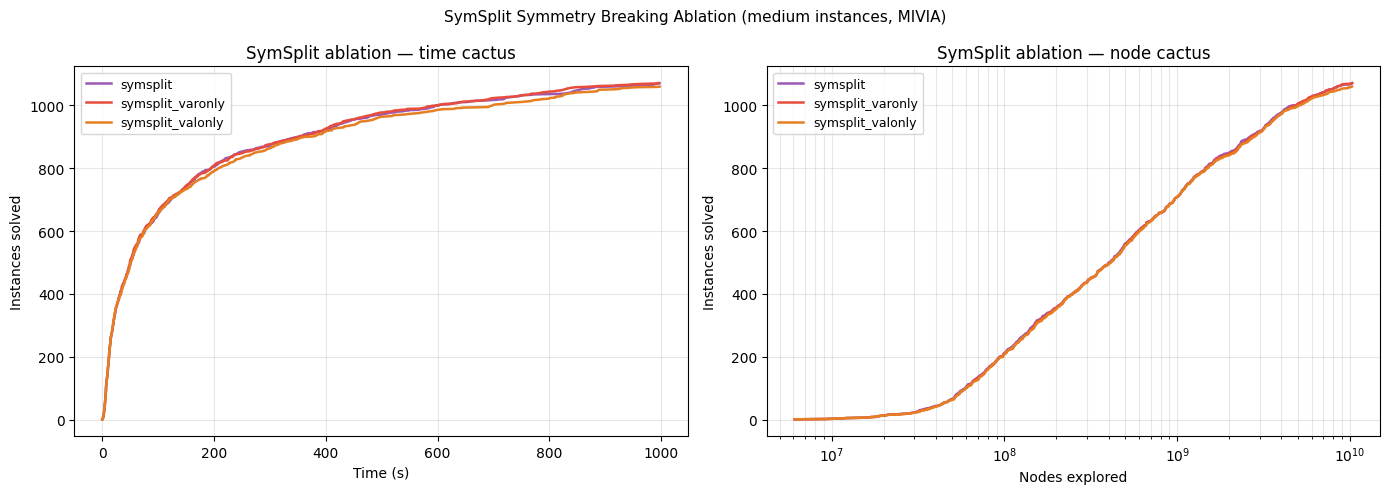

Saved: symsplit_ablation.png


In [27]:
SYM_ALGOS = ['symsplit', 'symsplit_varonly', 'symsplit_valonly']

print('SymSplit ablation — medium instance performance:')
sym_summary = medium_summary(medium_data, SYM_ALGOS)
display(sym_summary.round(2))

SYM_COLORS = {'rrsplit': '#95a5a6', 'symsplit_varonly': '#e74c3c',
              'symsplit_valonly': '#e67e22', 'symsplit': '#9b59b6'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for algo in SYM_ALGOS:
    sub = medium_data[(medium_data['algo'] == algo) & (medium_data['unified_aborted'] == 0)]
    if sub.empty: continue
    times = sub['unified_time'].sort_values().values
    axes[0].plot(times, np.arange(1, len(times)+1), label=algo,
                 color=SYM_COLORS.get(algo, 'gray'), linewidth=1.8)
axes[0].set_ylabel('Instances solved')
axes[0].set_xlabel('Time (s)')
axes[0].set_title('SymSplit ablation — time cactus')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

for algo in SYM_ALGOS:
    sub = medium_data[(medium_data['algo'] == algo) & (medium_data['unified_aborted'] == 0)]
    if sub.empty: continue
    nodes = sub['unified_nodes'].sort_values().values
    axes[1].plot(nodes, np.arange(1, len(nodes)+1), label=algo,
                 color=SYM_COLORS.get(algo, 'gray'), linewidth=1.8)
axes[1].set_xlabel('Nodes explored')
axes[1].set_ylabel('Instances solved')
axes[1].set_xscale('log')
axes[1].set_title('SymSplit ablation — node cactus')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, which='both')

plt.suptitle('SymSplit Symmetry Breaking Ablation (medium instances, MIVIA)', fontsize=11)
plt.tight_layout()
plt.savefig('symsplit_ablation.png', dpi=150)
plt.show()
print('Saved: symsplit_ablation.png')

### 10. Summary Table — All Ablation Variants

In [28]:
# Group ablation variants by parent algorithm
GROUPS = {
    'McSplit (baseline)': ['mcsplit'],
    'McSplit+RL': ['rl'],
    'McSplit+LL': ['ll', 'll_lum', 'll_lsm'],
    'McSplit+DAL': ['dal', 'dal_rl', 'dal_dal'],
    'McSplit+DSB': ['dsb', 'dsb_never', 'dsb_always'],
    'RRSplit': ['rrsplit', 'rrsplit_nobound', 'rrsplit_nomax', 'rrsplit_noveq'],
    'SymSplit': ['symsplit', 'symsplit_varonly', 'symsplit_valonly'],
}

ALGO_ORDER_FULL = [a for algos in GROUPS.values() for a in algos]

print('Complete ablation summary (medium instances):')
full_summary = medium_summary(medium_data, ALGO_ORDER_FULL).reindex(ALGO_ORDER_FULL)
print(full_summary[['solved', 'solved_pct']].round(2))

Complete ablation summary (medium instances):
                  solved  solved_pct
algo                                
mcsplit             1037      95.840
rl                   976      90.200
ll                  1026      94.820
ll_lum              1017      93.990
ll_lsm              1018      94.090
dal                  996      92.050
dal_rl               849      78.470
dal_dal              842      77.820
dsb                 1030      95.190
dsb_never           1036      95.750
dsb_always          1037      95.840
rrsplit             1057      97.690
rrsplit_nobound     1064      98.340
rrsplit_nomax       1067      98.610
rrsplit_noveq       1064      98.340
symsplit            1071      98.980
symsplit_varonly    1071      98.980
symsplit_valonly    1060      97.970


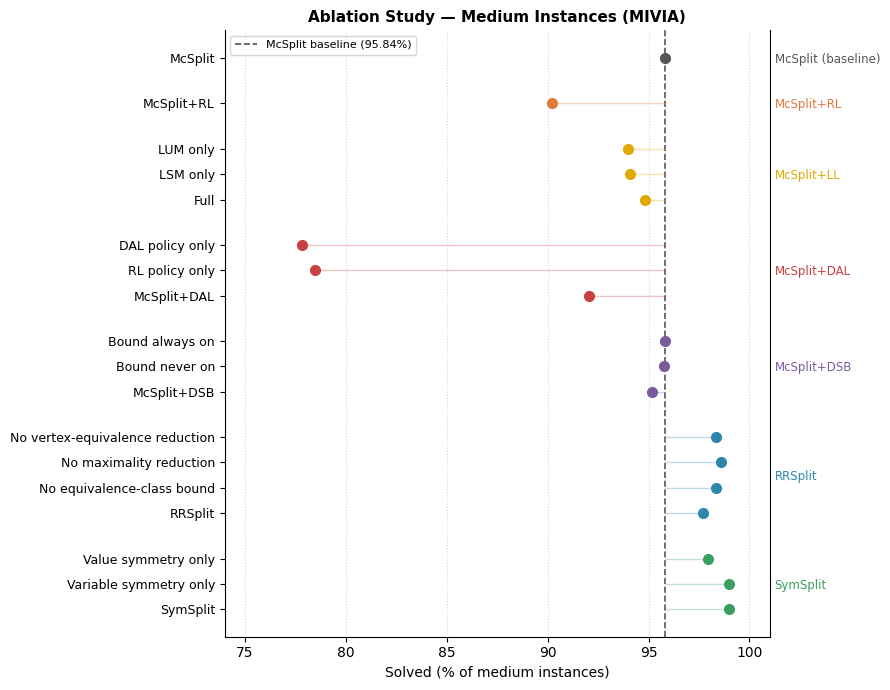

In [32]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

data = {
    'mcsplit':          ('McSplit (baseline)', 95.84),
    'rl':               ('McSplit+RL',         90.20),
    'll':               ('McSplit+LL',         94.82),
    'll_lsm':           ('McSplit+LL',         94.09),
    'll_lum':           ('McSplit+LL',         93.99),
    'dal':              ('McSplit+DAL',        92.05),
    'dal_rl':           ('McSplit+DAL',        78.47),
    'dal_dal':          ('McSplit+DAL',        77.82),
    'dsb':              ('McSplit+DSB',        95.19),
    'dsb_never':        ('McSplit+DSB',        95.75),
    'dsb_always':       ('McSplit+DSB',        95.84),
    'rrsplit':          ('RRSplit',            97.69),
    'rrsplit_nobound':  ('RRSplit',            98.34),
    'rrsplit_nomax':    ('RRSplit',            98.61),
    'rrsplit_noveq':    ('RRSplit',            98.34),
    'symsplit':         ('SymSplit',           98.98),
    'symsplit_varonly': ('SymSplit',           98.98),
    'symsplit_valonly': ('SymSplit',           97.96),
}

GROUPS = {
    'McSplit (baseline)': ['mcsplit'],
    'McSplit+RL':         ['rl'],
    'McSplit+LL':         ['ll', 'll_lsm', 'll_lum'],
    'McSplit+DAL':        ['dal', 'dal_rl', 'dal_dal'],
    'McSplit+DSB':        ['dsb', 'dsb_never', 'dsb_always'],
    'RRSplit':            ['rrsplit', 'rrsplit_nobound', 'rrsplit_nomax', 'rrsplit_noveq'],
    'SymSplit':           ['symsplit', 'symsplit_varonly', 'symsplit_valonly'],
}

LABELS = {
    'mcsplit':          'McSplit',
    'rl':               'McSplit+RL',
    'll':               'Full',
    'll_lsm':           'LSM only',
    'll_lum':           'LUM only',
    'dal':              'McSplit+DAL',
    'dal_rl':           'RL policy only',
    'dal_dal':          'DAL policy only',
    'dsb':              'McSplit+DSB',
    'dsb_never':        'Bound never on',
    'dsb_always':       'Bound always on',
    'rrsplit':          'RRSplit',
    'rrsplit_nobound':  'No equivalence-class bound',
    'rrsplit_nomax':    'No maximality reduction',
    'rrsplit_noveq':    'No vertex-equivalence reduction',
    'symsplit':         'SymSplit',
    'symsplit_varonly': 'Variable symmetry only',
    'symsplit_valonly': 'Value symmetry only',
}

GROUP_COLORS = {
    'McSplit (baseline)': '#555555',
    'McSplit+RL':         '#e07b39',
    'McSplit+LL':         '#e0a800',
    'McSplit+DAL':        '#c94040',
    'McSplit+DSB':        '#7a5c9e',
    'RRSplit':            '#2e86ab',
    'SymSplit':           '#3a9e5f',
}

BASELINE = 95.84

fig, ax = plt.subplots(figsize=(9, 7))

y = 0
yticks = []
yticklabels = []
group_midpoints = {}

for group, algos in reversed(list(GROUPS.items())):
    group_start = y
    for algo in algos:
        _, pct = data[algo]
        color = GROUP_COLORS[group]
        ax.plot(pct, y, 'o', color=color, markersize=7, zorder=3)
        ax.plot([BASELINE, pct], [y, y], color=color, alpha=0.3, linewidth=1, zorder=2)
        yticks.append(y)
        yticklabels.append(LABELS[algo])
        y += 1
    group_midpoints[group] = (group_start + y - 1) / 2
    y += 0.8  # gap between groups

ax.axvline(BASELINE, color='#555555', linestyle='--', linewidth=1.2,
           label=f'McSplit baseline ({BASELINE}%)', zorder=1)

ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels, fontsize=9)
ax.set_xlabel('Solved (% of medium instances)', fontsize=10)
ax.set_title('Ablation Study — Medium Instances (MIVIA)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
ax.set_xlim(74, 101)
ax.grid(axis='x', linestyle=':', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# group labels on right
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks(list(group_midpoints.values()))
ax2.set_yticklabels(list(group_midpoints.keys()), fontsize=8.5)
ax2.tick_params(length=0)
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)

# colour the right-axis labels to match dots
for label, group in zip(ax2.get_yticklabels(), group_midpoints.keys()):
    label.set_color(GROUP_COLORS[group])

plt.tight_layout()
plt.savefig('ablation_dotplot.pdf', bbox_inches='tight')
plt.show()